In [1]:
import fluid_flow_1d_lofi_linear as lofi
import fluid_flow_1d_hifi_eval as hifi
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
import importlib

Succesfully imported fluid_flow_1d_lofi_linear


In [2]:
vertex_plot = lambda x, *args, **kwargs: plt.plot(lofi.np.linspace(0,1,lofi.K.dim()), lofi.fenics_convert(x, 'vertex', lofi.K), *args, **kwargs)

## Highlighting nonlinearity

In [345]:
importlib.reload(hifi)
importlib.reload(lofi)

# Load data from mat file 
import scipy.io as sio 
z_lofi = sio.loadmat("../../data/lofi_optim_sol.mat")['k0_opt_lofi']
z_hifi = sio.loadmat("../../data/hifi_optim_sol.mat")['k0_hifi']

# u_n = lofi.Function(lofi.U)
# lofi.u_timeseries.retrieve(u_n.vector(), 0)
# plt.plot(lofi.fenics_convert(u_n, 'vertex', lofi.U))

discrepancy_end = lambda x: hifi.state_solve(x, return_type="vector", return_all=False) - lofi.state_solve(x, return_type="vector", annotate=False, return_all=False)
d_lofi = discrepancy_end(z_lofi)
d_hifi = discrepancy_end(z_hifi)

kt_hifi = hifi.state_solve(z_hifi, return_type="vector", return_all=False)
kt_lofi = lofi.state_solve(z_hifi, return_type="vector", return_all=False)

Succesfully imported fluid_flow_1d_lofi_linear


Discrepancy Percentage at Hi-Fi: 35.65%

Linearization Error (relative to discrepancy): 24.90%


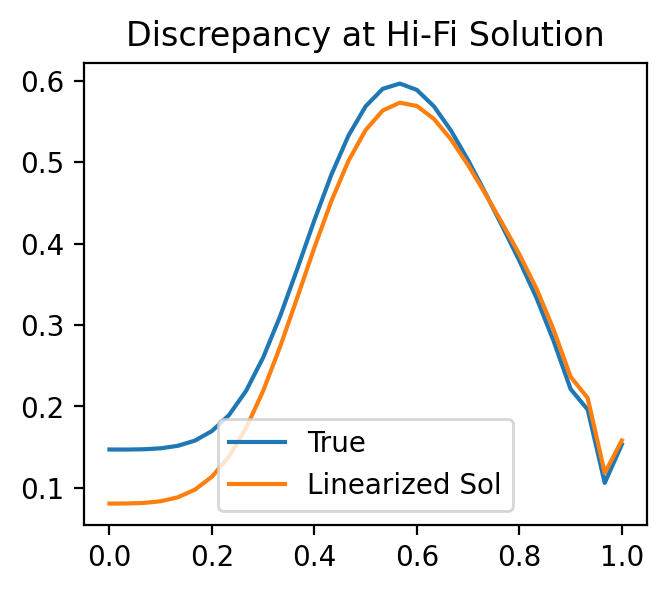

In [347]:
h = 1e-5
d_lin_est = d_lofi + (discrepancy_end(z_lofi + h*(z_hifi-z_lofi))-d_lofi)/h
print(f"Discrepancy Percentage at Hi-Fi: {100*lofi.np.linalg.norm(d_hifi)/lofi.np.linalg.norm(kt_hifi):.2f}%")
print()
print(f"Linearization Error (relative to discrepancy): {100*lofi.np.linalg.norm(d_hifi-d_lin_est)/lofi.np.linalg.norm(d_hifi):.2f}%")
# print(f"Linearization Error (relative to state): {100*lofi.np.linalg.norm(d_hifi-d_lin_est)/lofi.np.linalg.norm(kt_hifi):.2f}%")

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
vertex_plot(kt_hifi+d_hifi, label='True')
vertex_plot(kt_hifi+d_lin_est, label=r'Linearized Sol')
plt.title("Discrepancy at Hi-Fi Solution")
plt.legend();

In [224]:
# importlib.reload(hifi)
# kt_hifi = hifi.state_solve(z_hifi, return_type="vector", return_all=False);


In [ ]:
# kt_hifi_0 = kt_hifi
# print(100*lofi.np.linalg.norm(kt_hifi - kt_hifi_0)/lofi.np.linalg.norm(kt_hifi_0), "%")
# plt.plot(abs(kt_hifi - kt_hifi_0)/kt_hifi_0)

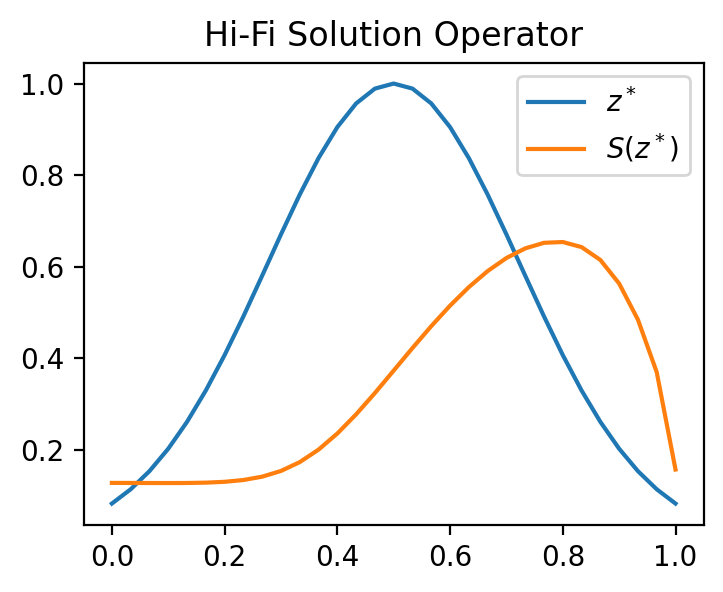

In [340]:
plt.figure(figsize=(4,3))
vertex_plot(z_hifi, label=r'$z^*$')
vertex_plot(kt_hifi, label=r'$S(z^*)$')
plt.title("Hi-Fi Solution Operator")
plt.legend();

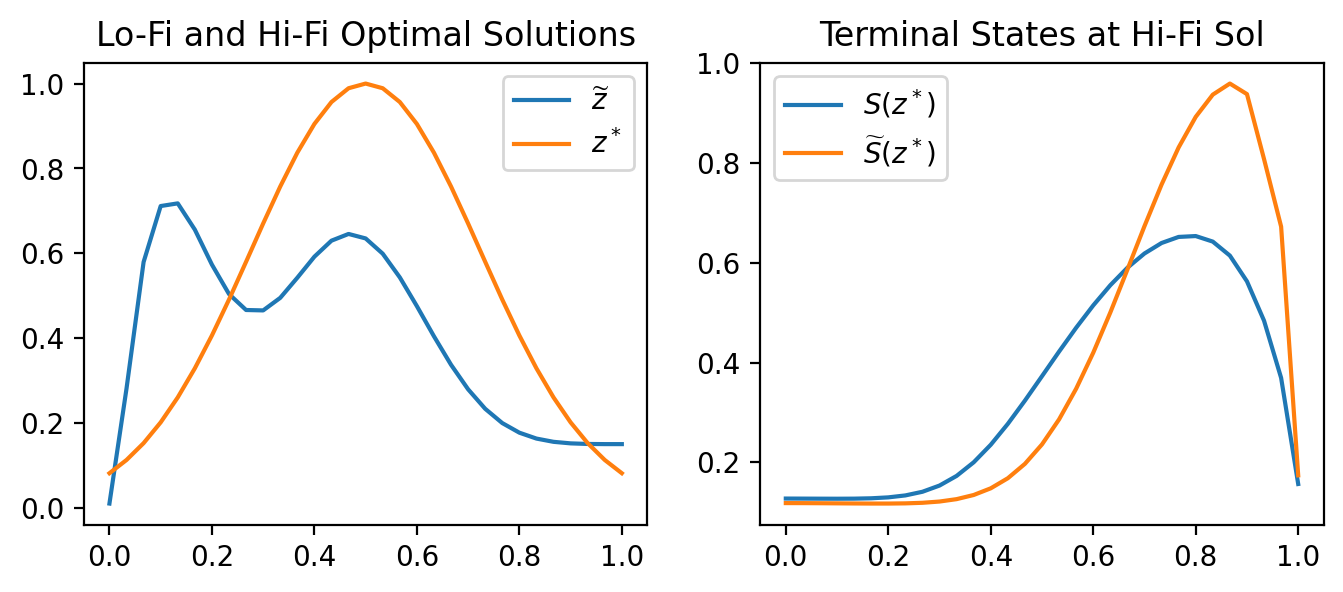

In [344]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
vertex_plot(z_lofi, label=r'$\widetilde{z}$')
vertex_plot(z_hifi, label=r'$z^*$')
plt.title("Lo-Fi and Hi-Fi Optimal Solutions")
plt.legend();

plt.subplot(1, 2, 2)
vertex_plot(kt_hifi, label=r'$S(z^*)$')
vertex_plot(kt_lofi, label=r'$\widetilde{S}(z^*)$')
plt.title("Terminal States at Hi-Fi Sol")
plt.legend();


In [228]:
kt_full_hifi = hifi.state_solve(z_hifi, return_type="vector", return_all=True)
kt_full_lofi = lofi.state_solve(z_hifi, return_type="vector", return_all=True)

In [212]:
#35, 9, 2 (1) -> 21, 19, 3 (10) -> 15, 23, 3 (20) -> 25, 21, 4 (20; 100k) -> 27, 24, 5 (40; 200k) -> 37, 26, 7 (30; 300k)

Essentially, the issue is that there's a balance between magnitude and nonlinearity: 
- if we want nonlinearity, then the magnitude of discrepancy is small
- if we want large discrepancies, then there is little (relative) nonlinearity


| Scale | Amount of Discrepancy | Lin. err. (rel. to disc) | Lin. err. (rel. to state) |
| ----- | --------------------- | ------------------------ | ------------------------- |
| 1,000 | 1% | 25% | 0.3% |
| 5,000 | 6% | 20% | 1% |
| 10,000 | 12% | 15% | 2% |
| 50,000 | 30% | 11% | 3% |
| 100,000 | 45% | 5% | 1.5% |

In [11]:
alphas = [0, 0.5, 1]
zs = {alpha: z_lofi + alpha * (z_hifi - z_lofi) for alpha in alphas}
ds = {alpha: discrepancy_end(zs[alpha]) for alpha in alphas}

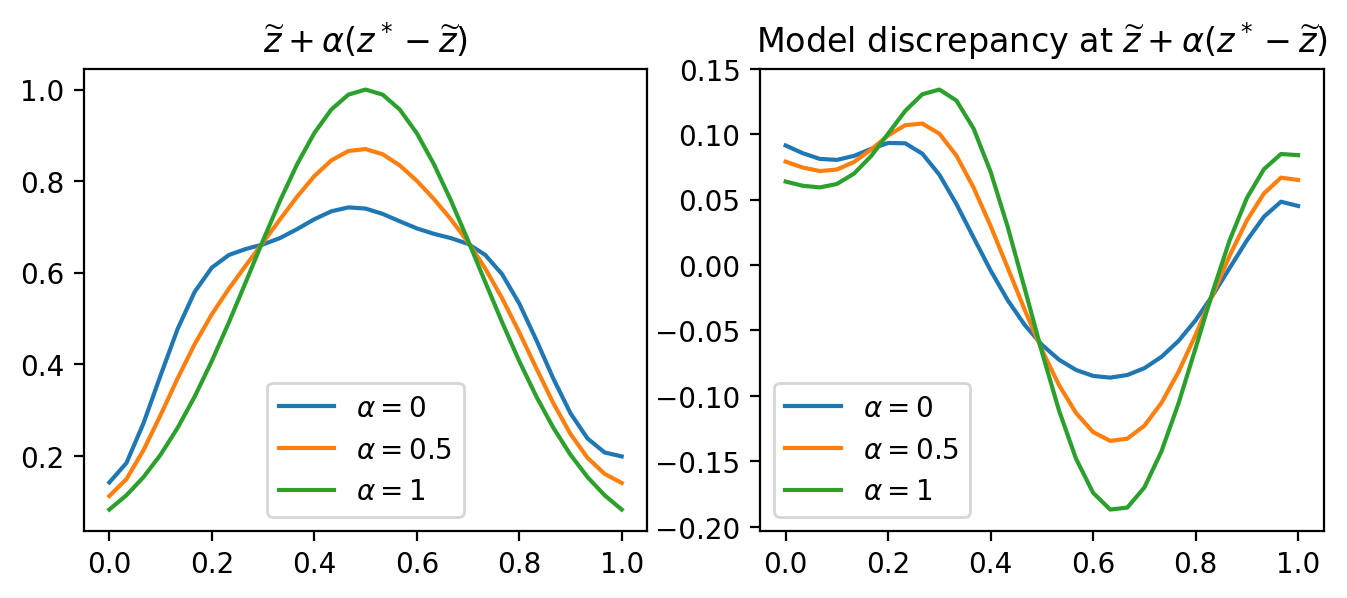

In [12]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
for alpha in alphas: vertex_plot(zs[alpha], label=r'$\alpha = '+str(alpha)+'$')
plt.title(r"$\widetilde{z} + \alpha(z^* - \widetilde{z})$")
plt.legend();

plt.subplot(1, 2, 2)
for alpha in alphas: vertex_plot(ds[alpha], label=r'$\alpha = '+str(alpha)+'$')
plt.title(r"Model discrepancy at $\widetilde{z} + \alpha(z^* - \widetilde{z})$")
plt.legend();

## Finite-Difference Checks

In [22]:
h = 1.e-4
e1 = lofi.np.zeros_like(kt_lofi)
e1[1-1] = 1;
he1 = h*e1;
print("\nFinite-Difference Check for lofi.misfit_gradient:")
print((lofi.J(k0, kt_lofi+he1) - lofi.J(k0, kt_lofi))/h)
print(lofi.misfit_gradient(kt_lofi, k0)[1-1])

print("\nFinite-Difference Check for lofi.apply_misfit_hessian:")
print((lofi.misfit_gradient(kt_lofi+he1, k0) - lofi.misfit_gradient(kt_lofi, k0))/h)
print(lofi.apply_misfit_hessian(lofi.np.pad(e1, ((lofi.N+1)*lofi.num_steps-(lofi.N+1), 0), 'constant'), k0, kt_lofi)[-(lofi.N+1):])

print("\nFinite-Difference Check for lofi.apply_solution_operator_z_jacobian:")
fd_val = (lofi.state_solve(k0 + he1, return_type="vector", annotate=False, return_all=True) - lofi.state_solve(k0, return_type="vector", annotate=False, return_all=True))/h;
test_val = lofi.apply_solution_operator_z_jacobian(e1, k0)
print(fd_val[-31:-20])
print(test_val[-31:-20])

print("\nVerification for lofi.apply_solution_operator_z_jacobian_transpose:")
e2 = lofi.np.zeros_like(kt_lofi); e2[2-1] = 1;
e2_padded = lofi.np.pad(e2, ((lofi.N+1)*lofi.num_steps-(lofi.N+1), 0), 'constant');
print(lofi.np.dot(e2_padded, lofi.apply_solution_operator_z_jacobian(e1, k0)))
print(lofi.np.dot(e1, lofi.apply_solution_operator_z_jacobian_transpose(e2_padded, k0)))


Finite-Difference Check for lofi.misfit_gradient:
288.3877037629645
288.38214820330217

Finite-Difference Check for lofi.apply_misfit_hessian:
[111.11111111  55.55555555   0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.        ]
[111.11111111  55.55555556   0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.        ]

Finite-Difference Check for lofi.apply_solution_operator_z_jacobian:
[ 3.04877630e-04  3.16814757e-04  3.28144645e-05 -5.15024245

In [3]:
h = 1.e-4
e1 = lofi.np.zeros_like(kt_lofi)
e1[1-1] = 1;
he1 = h*e1;
print("Finite-Difference Check for lofi.misfit_gradient:")
print((lofi.J(k0, kt_lofi+he1) - lofi.J(k0, kt_lofi))/h)
print(lofi.misfit_gradient(kt_lofi, k0)[1-1])

print("\nFinite-Difference Check for lofi.apply_misfit_hessian:")
print((lofi.misfit_gradient(kt_lofi+he1, k0) - lofi.misfit_gradient(kt_lofi, k0))/h)
print(lofi.apply_misfit_hessian(lofi.np.pad(e1, ((lofi.N+1)*lofi.num_steps-(lofi.N+1), 0), 'constant'), k0, kt_lofi)[-(lofi.N+1):])

print("\nFinite-Difference Check for lofi.apply_solution_operator_z_jacobian:")
fd_val = (lofi.state_solve(k0 + he1, return_type="vector", annotate=False, return_all=True) - lofi.state_solve(k0, return_type="vector", annotate=False, return_all=True))/h;
test_val = lofi.apply_solution_operator_z_jacobian(e1, k0)
print(fd_val[-31:-20])
print(test_val[-31:-20])

print("\nVerification for lofi.apply_solution_operator_z_jacobian_transpose:")
e2 = lofi.np.zeros_like(kt_lofi); e2[2-1] = 1;
e2_padded = lofi.np.pad(e2, ((lofi.N+1)*lofi.num_steps-(lofi.N+1), 0), 'constant');
print(lofi.np.dot(e2_padded, lofi.apply_solution_operator_z_jacobian(e1, k0)))
print(lofi.np.dot(e1, lofi.apply_solution_operator_z_jacobian_transpose(e2_padded, k0)))

Finite-Difference Check for lofi.misfit_gradient:
359.9404671786033
359.93491162182573

Finite-Difference Check for lofi.apply_misfit_hessian:
[111.11111111  55.55555556   0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.        ]
[111.11111111  55.55555556   0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.        ]

Finite-Difference Check for lofi.apply_solution_operator_z_jacobian:
[ 4.49712366e-03  4.56332941e-03  2.36795861e-03  7.62145951e

In [23]:
# u_timeseries_lofi = lofi.TimeSeries(f"{lofi.root_path}/../../data/velocity_timeseries_lofi_1d")
# u_timeseries_midfi = lofi.TimeSeries(f"{lofi.root_path}/../../data/velocity_timeseries_midfi_1d")
# u_l = lofi.Function(lofi.U)
# u_m = lofi.Function(lofi.U)
# u_timeseries_lofi.retrieve(u_l.vector(), 0.01)
# u_timeseries_midfi.retrieve(u_m.vector(), 0.01)
# plt.plot(u_l.vector()[:])
# plt.plot(u_m.vector()[:])


In [24]:
# kt_lofi_fn = lofi.state_solve(k0, return_type="function")
# k0_fn = lofi.interpolate(lofi.Expression("10*pow(x[0],2)*pow(0.1*x[0]-1,2)", degree=2), lofi.K)
# plt.plot(kt_hifi)
# lofi.assemble(kt_hifi_fn.dx(0) * lofi.TestFunction(lofi.K) * lofi.dx)[:]

## Analyzing Discrepancy Behavior

In [333]:
k0_1 = lofi.interpolate(lofi.Expression("5*pow(x[0],2)*pow(x[0]-1,2)", degree=2), lofi.K).vector()[:]
k0_2 = lofi.interpolate(lofi.Expression("pow(x[0], 3)-1.5*pow(x[0], 2)+0.5", degree=2), lofi.K).vector()[:]


In [561]:
import os
os.remove(f"{lofi.root_path}/../../data/velocity_timeseries_midfi_1d.h5")
importlib.reload(hifi)
hifi.state_solve(0*k0_1, return_type="vector", return_all=True, store_midfi=True);

[2.         1.93906665 1.93819354 1.94026492 1.94376589 1.9478564
 1.95236272 1.95709825 1.96198564 1.9669659  1.97200751 1.97708866
 1.98219624 1.98732135 1.99245824 1.9976029  2.00275239 2.00790413
 2.01305518 2.01820096 2.02333308 2.02843468 2.03347126 2.03837182
 2.04299056 2.04703018 2.04988905 2.05036039 2.04605126 2.03226723
 2.        ]
[2.         1.93906665 1.93819354 1.94026492 1.94376589 1.9478564
 1.95236272 1.95709825 1.96198564 1.9669659  1.97200751 1.97708866
 1.98219624 1.98732135 1.99245824 1.9976029  2.00275239 2.00790413
 2.01305518 2.01820096 2.02333308 2.02843468 2.03347126 2.03837182
 2.04299056 2.04703018 2.04988905 2.05036039 2.04605126 2.03226723
 2.        ]
[2.         1.93906665 1.93819354 1.94026492 1.94376589 1.9478564
 1.95236272 1.95709825 1.96198564 1.9669659  1.97200751 1.97708866
 1.98219624 1.98732135 1.99245824 1.9976029  2.00275239 2.00790413
 2.01305518 2.01820096 2.02333308 2.02843468 2.03347126 2.03837182
 2.04299056 2.04703018 2.04988905 2.050

In [600]:
importlib.reload(lofi)
importlib.reload(hifi)

Succesfully imported fluid_flow_1d_lofi


<module 'fluid_flow_1d_hifi_eval' from '/Users/mmadhav/GitRepos/sabl/examples/Transient_Fluid_Flow_Tracer_1D/python/serverside/fluid_flow_1d_hifi_eval.py'>

[2.         0.84883967 0.90179379 0.86841882 0.90140841 0.93788045
 0.99777516 1.06934128 1.15454949 1.24966611 1.35384186 1.46510455
 1.58221781 1.7037327  1.82843885 1.95511622 2.08267398 2.21009676
 2.3365028  2.46109672 2.58306636 2.70127944 2.8137398  2.91669885
 3.00338171 3.06229661 3.07523537 3.01560793 2.84756227 2.5437622
 2.        ]
[2.         1.93906665 1.93819354 1.94026492 1.94376589 1.9478564
 1.95236272 1.95709825 1.96198564 1.9669659  1.97200751 1.97708866
 1.98219624 1.98732135 1.99245824 1.9976029  2.00275239 2.00790413
 2.01305518 2.01820096 2.02333308 2.02843468 2.03347126 2.03837182
 2.04299056 2.04703018 2.04988905 2.05036039 2.04605126 2.03226723
 2.        ]
[2.         0.87087589 0.92588301 0.89186962 0.92270713 0.95649343
 1.01333079 1.08157791 1.16324672 1.25464888 1.3549828  1.46233387
 1.57553126 1.6932008  1.81421433 1.93744246 2.06189316 2.18666119
 2.3109905  2.43423464 2.55575781 2.67462446 2.78902087 2.8952896
 2.98652589 3.05071403 3.06857015 3.011

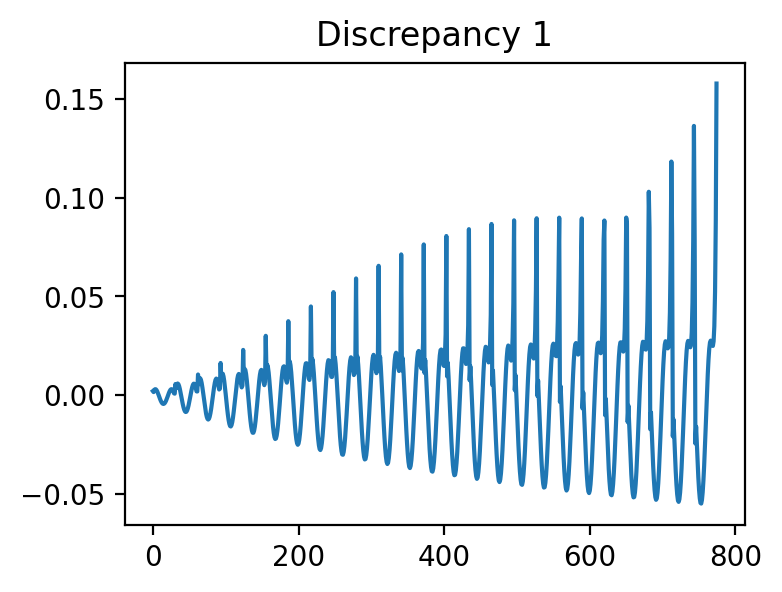

In [601]:
kt_1_lofi = lofi.state_solve(k0_1, return_type="vector", annotate=False, return_all=True)
kt_1_hifi = hifi.state_solve(k0_1, return_type="vector", return_all=True)
disc_1 = kt_1_hifi - kt_1_lofi;
plt.figure(figsize=(4, 3))
plt.plot(disc_1);
plt.title("Discrepancy 1");
print(f"Relative magnitude of discrepancy: {100*lofi.np.linalg.norm(disc_1)/lofi.np.linalg.norm(kt_1_lofi):.2f}%")

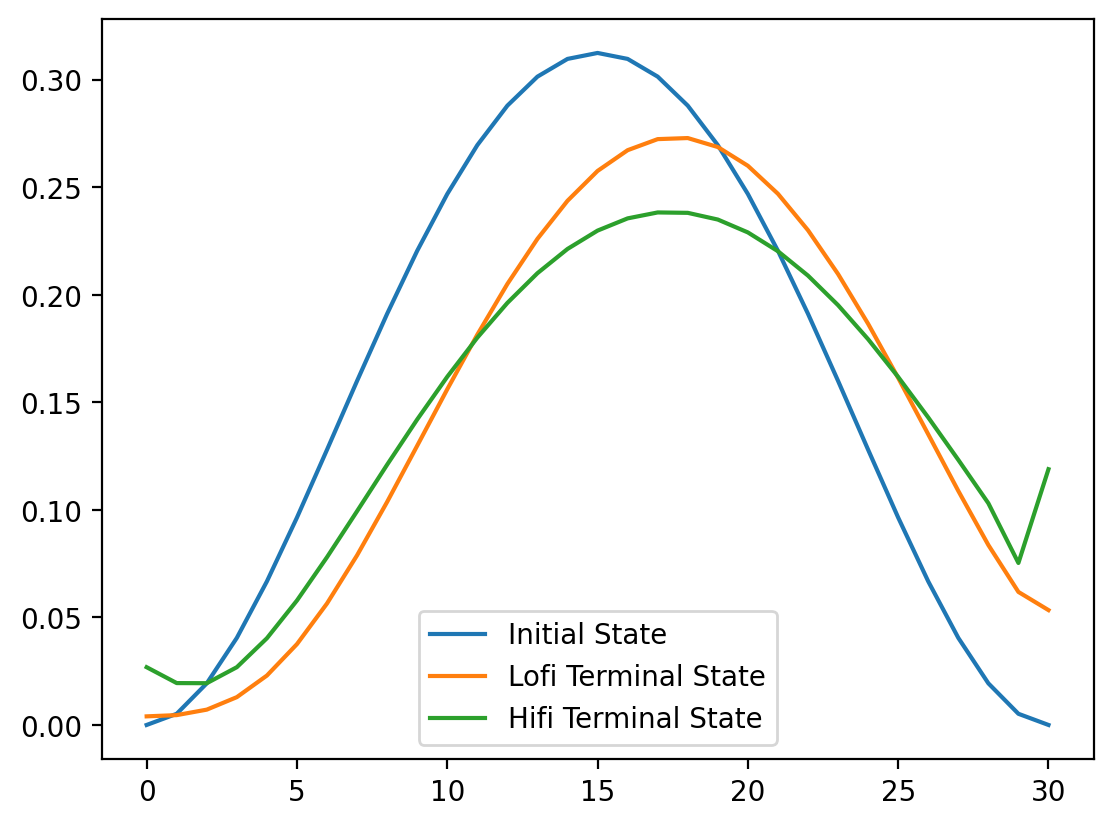

In [607]:
i=10
vertex_plot(k0_1, label='Initial State')
vertex_plot(kt_1_lofi[31*i:31*(i+1)], label='Lofi Terminal State')
vertex_plot(kt_1_hifi[31*i:31*(i+1)], label='Hifi Terminal State')
plt.legend()

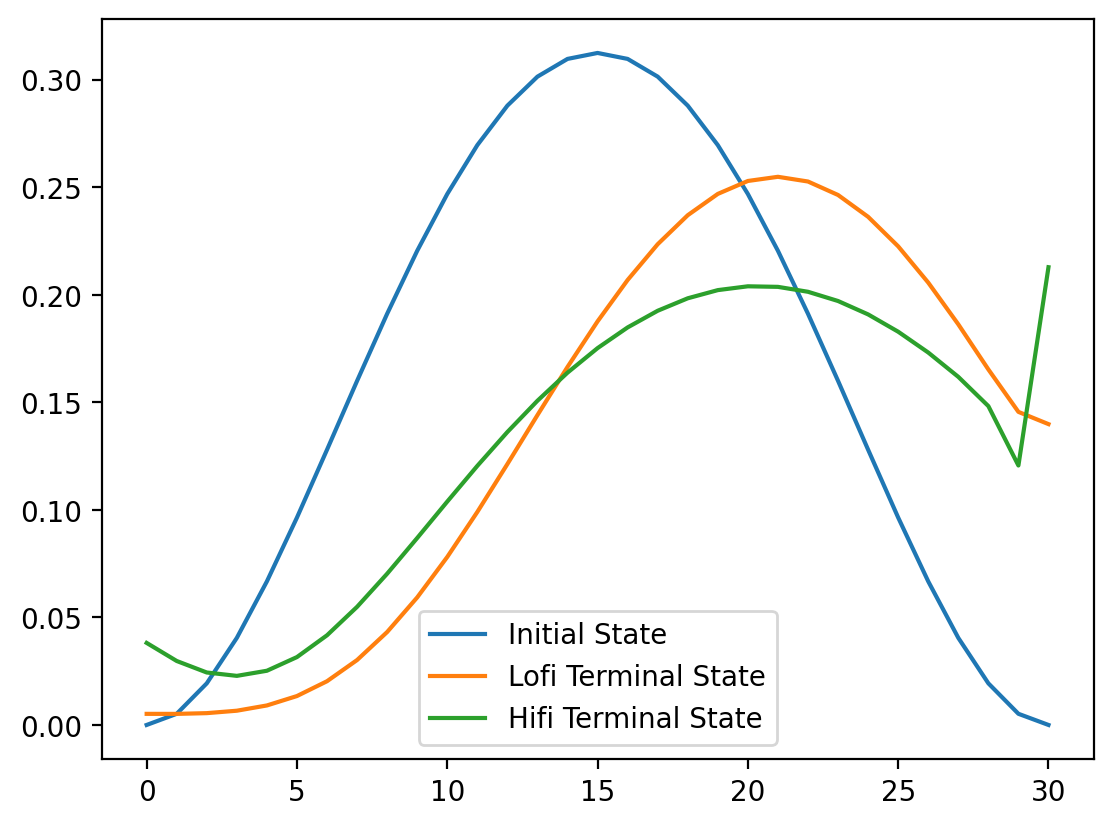

In [589]:
vertex_plot = lambda x, *args, **kwargs: plt.plot(lofi.fenics_convert(x, 'vertex', lofi.K), *args, **kwargs)
vertex_plot(k0_1, label='Initial State')
vertex_plot(kt_1_lofi[-31:], label='Lofi Terminal State')
vertex_plot(kt_1_hifi[-31:], label='Hifi Terminal State')
plt.legend()

Relative magnitude of discrepancy: 46.13%


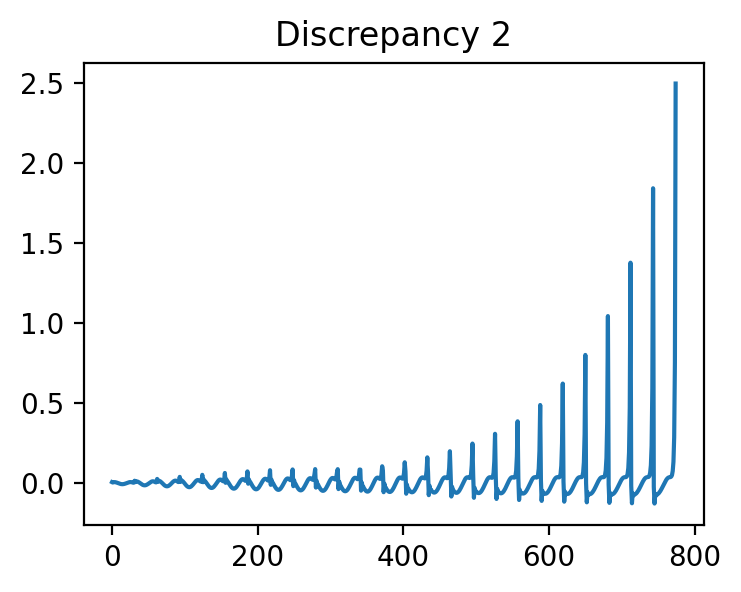

In [439]:
kt_2_lofi = lofi.state_solve(2*k0_1, return_type="vector", annotate=False, return_all=True)
kt_2_hifi = hifi.state_solve(2*k0_1, return_type="vector", return_all=True)
disc_2 = kt_2_hifi - kt_2_lofi;
plt.figure(figsize=(4, 3))
plt.plot(disc_2);
plt.title("Discrepancy 2");
print(f"Relative magnitude of discrepancy: {100*lofi.np.linalg.norm(disc_2)/lofi.np.linalg.norm(kt_2_lofi):.2f}%")

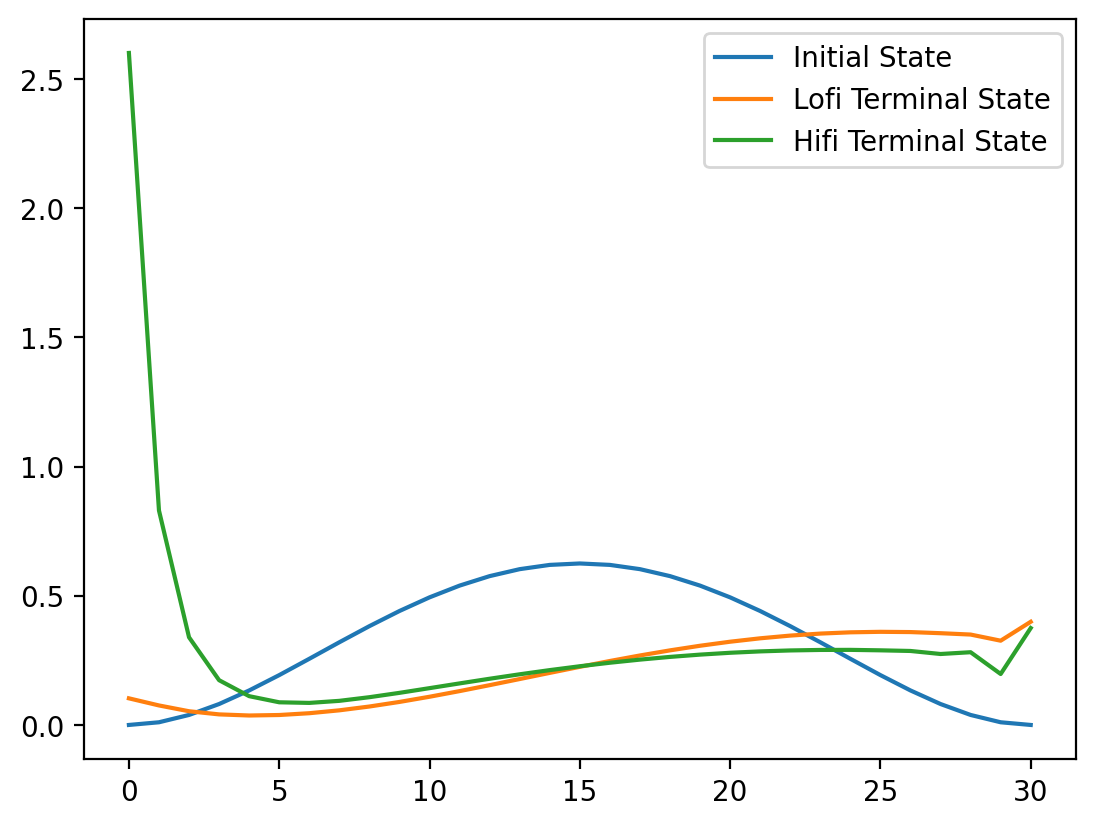

In [460]:
vertex_plot(2*k0_1, label='Initial State')
vertex_plot(kt_2_lofi[-31:], label='Lofi Terminal State')
vertex_plot(kt_2_hifi[-31:], label='Hifi Terminal State')
plt.legend()

In [430]:
# Check whether discrepancy behaves linearly
print(f"Relative diff between 2*disc_1 and disc_2: {lofi.np.linalg.norm(disc_2 - 2*disc_1)/lofi.np.linalg.norm(disc_2)*100:.2f}%")

Relative diff between 2*disc_1 and disc_2: 83.39%


In [179]:
u_timeseries = hifi.TimeSeries(f"{hifi.root_path}/../../data/velocity_timeseries_midfi_1d")


In [202]:
u_test = lofi.Function(lofi.U)
for t in range(25):
    u_timeseries.retrieve(u_test.vector(), t*0.02)
    print(u_test.vector()[:])

[1.96078431 1.928209   1.94583374 1.89560092 1.91302885 1.86298834
 1.88023412 1.83036552 1.84746046 1.79773423 1.8147012  1.76509483
 1.78195423 1.7324481  1.74921718 1.69979475 1.71648824 1.6671355
 1.68376593 1.63447104 1.65104902 1.60180201 1.61833652 1.56912896
 1.58562758 1.53645242 1.55292153 1.50377279 1.52021776 1.47109053
 1.4875158  1.4384058  1.4548152  1.40571912 1.42211559 1.37303016
 1.38941663 1.34033996 1.35671798 1.3076469  1.32401936 1.27495388
 1.29132038 1.24225568 1.25862086 1.20956084 1.22592001 1.17685405
 1.19321822 1.14415988 1.16051311 1.11143548 1.12780726 1.07874809
 1.09509285 1.04598204 1.06237948 1.01331474 1.02964186 0.98039216
 0.99689543]
[1.96078431 1.928209   1.94583374 1.89560092 1.91302885 1.86298834
 1.88023412 1.83036552 1.84746046 1.79773423 1.8147012  1.76509483
 1.78195423 1.7324481  1.74921718 1.69979475 1.71648824 1.6671355
 1.68376593 1.63447104 1.65104902 1.60180201 1.61833652 1.56912896
 1.58562758 1.53645242 1.55292153 1.50377279 1.5202

In [ ]:
# kt_lofi = lofi.state_solve(k0, return_type="vector", annotate=False, return_all=True)
# kt_lofi_copy = lofi_copy.state_solve(k0, return_type="vector", annotate=False, return_all=True)
# kt_hifi = hifi.state_solve(k0, return_type="vector", return_all=True)
# discrep_kt = kt_hifi - kt_lofi
# plt.plot(kt_lofi[:30], label="Lofi")
# # plt.plot(kt_hifi[:30], label="Hifi")
# plt.legend()
# plt.plot(kt_lofi[-30:], label="Lofi")
# plt.plot(kt_hifi[-30:], label="Hifi")
# plt.legend()

## Additional Tests

In [70]:
# Test if "important" four functions are working.
# print(lofi.apply_solution_operator_z_jacobian_transpose(kt_in_long, k0))
# print(lofi.misfit_gradient(kt_k0, k0))
# kt_in_long = lofi.np.repeat(kt_in, 25)
# print(lofi.apply_misfit_hessian(kt_in_long, k0, kt_k0).shape)
# print(lofi.apply_rs_hessian(k0_in, k0))

(775,)


In [15]:
# k0_a = lofi.interpolate(lofi.Expression("pow(x[0], 2)", degree=1), lofi.K).vector()[:]
# k0 = lofi.interpolate(lofi.Expression("1-4*pow(x[0] - 0.5, 2)", degree=2), lofi.K).vector()[:]
# k0 = lofi.interpolate(lofi.Expression("pow(x[0], 3)-1.5*pow(x[0], 2)+0.5", degree=2), lofi.K).vector()[:]
# k0_guess = lofi.interpolate(lofi.Expression("2*(0.4 < x[0] && x[0] < 0.6)", degree=1), lofi.K).vector()[:]
# k0 = k0_guess
# k0 = hifi.interpolate(hifi.Expression("x[0]*(1-x[0])*(9-10*x[0])", degree=1), hifi.C).vector()[:]
# k0 = lofi.interpolate(lofi.Expression("10*pow(x[0],2)*pow(x[0]-1,2)", degree=2), lofi.K).vector()[:]
kt_in = lofi.interpolate(lofi.Expression("pow(x[0], 3)", degree=2), lofi.K).vector()[:]
k0_in = lofi.interpolate(lofi.Expression("pow(x[0], 4)", degree=2), lofi.K).vector()[:]

In [22]:
# Hessian Finite Difference Check
hess_exact = lofi.apply_rs_hessian(k0_in, k0).flatten()
norm_hess_exact = lofi.np.linalg.norm(hess_exact)
dJ = lambda m: lofi.J_hat_np(m)*0 + lofi.J_hat_np.derivative(forget=None)
epsilon=0.1
hess_fd = (dJ(k0 + epsilon * k0_in) - dJ(k0 - epsilon * k0_in)) / (2 * epsilon)

print("Hessian Relative Diff: ", lofi.np.linalg.norm(hess_fd - hess_exact)/norm_hess_exact)

Hessian Relative Diff:  1.4346230451287843e-13


In [3]:
# Low-Fidelity Optimization Test 
k0_guess = lofi.fenics_convert(k0, "function", lofi.K);
k_n = lofi.state_solve(k0_guess, return_type = "function", plot_k=False, verbose=False, annotate=True);

# Set up inverse problem
J_inv = lofi.J(k0_guess, k_n)
control = lofi.Control(k0_guess)
J_hat = lofi.ReducedFunctional(J_inv, control)

# Solve Inverse Problem
with lofi.stop_verbose():
    k0_opt_lofi = lofi.minimize(J_hat, method="Newton-CG", callback=lofi.callback_call(J_hat), tol=1e-3, options={"disp": True})


Iteration  Objective Value      Gradient Norm  
---------------------------------------------
1          0.008899             0.001426       
2          0.000820             0.000074       
3          0.000759             0.000003       
4          0.000759             0.000000       
5          0.000759             0.000000       
Optimization terminated successfully.
         Current function value: 0.000759
         Iterations: 5
         Function evaluations: 5
         Gradient evaluations: 5
         Hessian evaluations: 25


In [6]:
# kt_lofi = lofi.state_solve(k0, "vector");
# u_end_lofi = lofi.Function(lofi.U)
# lofi.u_timeseries.retrieve(u_end_lofi.vector(), 0.1)
# print(u_end_lofi.vector()[:])
# plt.plot(u_end_lofi.vector()[:])


# kt_midfi = lofi.state_solve(k0, "vector");
# u_end_midfi = lofi.Function(lofi.U)
# lofi.u_timeseries.retrieve(u_end_midfi.vector(), 0.1)
# print(u_end_midfi.vector()[:])
# plt.plot(u_end_midfi.vector()[:])

In [8]:
# plt.plot(disc_k0_1)
# plt.plot(disc_k0_2)

## Speedening Linear System

In [4]:
import fluid_flow_1d_lofi_linear as lofi_fast

importlib.reload(lofi_fast)

Succesfully imported fluid_flow_1d_lofi_fast
Succesfully imported fluid_flow_1d_lofi_fast


<module 'fluid_flow_1d_lofi_fast' from '/Users/mmadhav/GitRepos/sabl/examples/Transient_Fluid_Flow_Tracer_1D/python/serverside/fluid_flow_1d_lofi_fast.py'>

In [103]:
%time lofi.apply_solution_operator_z_jacobian(z_hifi, z_lofi)

CPU times: user 3.22 s, sys: 1.95 s, total: 5.18 s
Wall time: 1.8 s


array([0.09606198, 0.1189668 , 0.16051595, 0.21100125, 0.27131243,
       0.34119868, 0.41966312, 0.50483564, 0.59395717, 0.68346501,
       0.76918991, 0.84665615, 0.91145826, 0.95967182, 0.98824561,
       0.99532101, 0.98043197, 0.94455583, 0.89000713, 0.82019065,
       0.73925004, 0.65166263, 0.5618351 , 0.47374991, 0.39069984,
       0.31513093, 0.24859652, 0.19181759, 0.14488972, 0.10814365,
       0.08796764, 0.10685739, 0.1262076 , 0.16818627, 0.22031142,
       0.28210515, 0.3533152 , 0.43278784, 0.51850186, 0.60755884,
       0.69628869, 0.78046512, 0.85562002, 0.9174274 , 0.96211237,
       0.98683178, 0.98997343, 0.97133   , 0.93212172, 0.87486418,
       0.80310141, 0.72104332, 0.63315924, 0.54378159, 0.45676763,
       0.37525364, 0.30151981, 0.2369718 , 0.1822711 , 0.13783035,
       0.1055763 , 0.09129583, 0.11635015, 0.13404806, 0.17618202,
       0.22979089, 0.29305478, 0.36552793, 0.44592618, 0.53207694,
       0.62094829, 0.70877156, 0.79127458, 0.86400925, 0.92274

In [ ]:
%time lofi_fast.apply_solution_operator_z_jacobian(z_hifi, z_lofi)

CPU times: user 315 ms, sys: 212 ms, total: 527 ms
Wall time: 176 ms


array([0.09606198, 0.1189668 , 0.16051595, 0.21100125, 0.27131243,
       0.34119868, 0.41966312, 0.50483564, 0.59395717, 0.68346501,
       0.76918991, 0.84665615, 0.91145826, 0.95967182, 0.98824561,
       0.99532101, 0.98043197, 0.94455583, 0.89000713, 0.82019065,
       0.73925004, 0.65166263, 0.5618351 , 0.47374991, 0.39069984,
       0.31513093, 0.24859652, 0.19181759, 0.14488972, 0.10814365,
       0.08796764, 0.10685739, 0.1262076 , 0.16818627, 0.22031142,
       0.28210515, 0.3533152 , 0.43278784, 0.51850186, 0.60755884,
       0.69628869, 0.78046512, 0.85562002, 0.9174274 , 0.96211237,
       0.98683178, 0.98997343, 0.97133   , 0.93212172, 0.87486418,
       0.80310141, 0.72104332, 0.63315924, 0.54378159, 0.45676763,
       0.37525364, 0.30151981, 0.2369718 , 0.1822711 , 0.13783035,
       0.1055763 , 0.09129583, 0.11635015, 0.13404806, 0.17618202,
       0.22979089, 0.29305478, 0.36552793, 0.44592618, 0.53207694,
       0.62094829, 0.70877156, 0.79127458, 0.86400925, 0.92274

: 

In [6]:
%time lofi_fast.apply_rs_hessian(z_hifi, z_lofi*2)

CPU times: user 1.08 s, sys: 772 ms, total: 1.85 s
Wall time: 651 ms


array([ 11.74560456,  33.76711246,  51.02090695,  70.37005719,
        90.90348543, 111.82539592, 132.55086184, 152.68000592,
       171.90018424, 189.88551342, 206.24156729, 220.50659323,
       232.19379739, 240.8505937 , 246.11517459, 247.75950676,
       245.71503612, 240.08139816, 231.12009633, 219.2356977 ,
       204.94737873, 188.85385978, 171.59484617, 153.81203747,
       136.11336481, 119.05188702, 103.19313051,  89.80530046,
        86.12464687, 145.2794009 , 140.59591455])

In [285]:
%time a2 = lofi.apply_solution_operator_z_jacobian(z_hifi, z_lofi)

CPU times: user 5.94 s, sys: 4.07 s, total: 10 s
Wall time: 3.35 s


array([0.09606198, 0.1189668 , 0.16051595, 0.21100125, 0.27131243,
       0.34119868, 0.41966312, 0.50483564, 0.59395717, 0.68346501,
       0.76918991, 0.84665615, 0.91145826, 0.95967182, 0.98824561,
       0.99532101, 0.98043197, 0.94455583, 0.89000713, 0.82019065,
       0.73925004, 0.65166263, 0.5618351 , 0.47374991, 0.39069984,
       0.31513093, 0.24859652, 0.19181759, 0.14488972, 0.10814365,
       0.08796764, 0.10685739, 0.1262076 , 0.16818627, 0.22031142,
       0.28210515, 0.3533152 , 0.43278784, 0.51850186, 0.60755884,
       0.69628869, 0.78046512, 0.85562002, 0.9174274 , 0.96211237,
       0.98683178, 0.98997343, 0.97133   , 0.93212172, 0.87486418,
       0.80310141, 0.72104332, 0.63315924, 0.54378159, 0.45676763,
       0.37525364, 0.30151981, 0.2369718 , 0.1822711 , 0.13783035,
       0.1055763 , 0.09129583, 0.11635015, 0.13404806, 0.17618202,
       0.22979089, 0.29305478, 0.36552793, 0.44592618, 0.53207694,
       0.62094829, 0.70877156, 0.79127458, 0.86400925, 0.92274

In [284]:
%time lofi.state_solve(z_hifi, return_type="vector")

CPU times: user 470 ms, sys: 327 ms, total: 797 ms
Wall time: 267 ms


array([0.34012639, 0.34955191, 0.40008112, 0.46990838, 0.54770168,
       0.62701969, 0.70297362, 0.7712428 , 0.82786503, 0.86941649,
       0.8932896 , 0.89794753, 0.88308447, 0.84965928, 0.79979598,
       0.73656675, 0.66369113, 0.5851966 , 0.50508709, 0.4270575 ,
       0.3542742 , 0.28922002, 0.23358673, 0.18819945, 0.15297892,
       0.12697943, 0.10854842, 0.0956316 , 0.08616187, 0.07851507,
       0.07285941])

## Benchmarking Solve Times

In [ ]:
# kt_in = kt_full_hifi
# kt = kt_full_lofi
# k0 = z_lofi

In [48]:
%timeit -r 2 -n 2 lofi.np.linalg.norm(lofi.apply_solution_operator_z_jacobian(z_hifi, z_lofi))

2.82 s ± 3.44 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [50]:
%timeit -r 2 -n 2 lofi.np.linalg.norm(lofi.apply_rs_hessian(z_hifi, z_lofi+1))

2.16 s ± 178 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [51]:
%timeit -r 2 -n 2 lofi.apply_solution_operator_z_jacobian_transpose(kt_in, k0)

668 ms ± 22.6 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [52]:
%timeit -r 2 -n 2 lofi.apply_misfit_hessian(kt_in, k0, kt);

111 μs ± 34.2 μs per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [53]:
%timeit -r 2 -n 2 lofi.misfit_gradient(kt, k0);

179 μs ± 16.3 μs per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [54]:
%timeit -r 2 -n 2 lofi.state_solve(z_hifi, return_type="vector", return_all=True);

268 ms ± 26.8 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)
